In [6]:
import numpy as np
from einops import rearrange, reduce, repeat
from PIL import Image
from pathlib import Path

In [4]:
folder_path = "./imgs"
path = Path(folder_path)
file_list = sorted(list(path.glob("*.png")))
if not file_list:
    print("There is no png file")

images = np.array([np.array(Image.open(p)) for p in file_list])

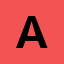

In [5]:
display(Image.fromarray(images[0]))

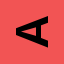

In [8]:
display(Image.fromarray(rearrange(images[0], "h w c -> w h c")))

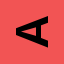

In [10]:
display(Image.fromarray(rearrange(images[0], "height width color -> width height color")))

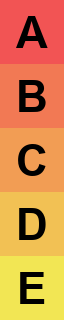

In [11]:
display(Image.fromarray(rearrange(images[:5], "b h w c -> (b h) w c")))

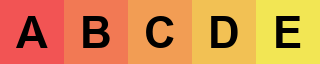

In [12]:
display(Image.fromarray(rearrange(images[:5], "b h w c -> h (b w) c")))

In [27]:
imgs = rearrange(images[:6], "(b1 b2) h w c -> b1 b2 h w c", b1=2)
print(f"imgs shape: {imgs.shape}")
imgs = rearrange(imgs, "b1 b2 h w c -> (b1 b2) h w c")
print(f"imgs shape: {imgs.shape}")
display(Image.fromarray(imgs))

imgs shape: (2, 3, 64, 64, 3)
imgs shape: (6, 64, 64, 3)


TypeError: Cannot handle this data type: (1, 1, 64, 3), |u1

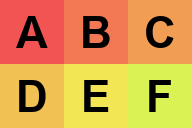

In [28]:
imgs = rearrange(images[0:6], "(b1 b2) h w c -> (b1 h) (b2 w) c", b1=2)
display(Image.fromarray(imgs))

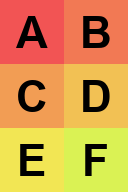

In [30]:
imgs = rearrange(images[:6], "(b1 b2) h w c -> (b1 h) (b2 w) c", b1=3)
display(Image.fromarray(imgs))

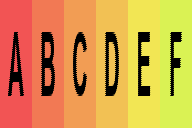

In [31]:
imgs = rearrange(images[:6], "b h (w w2) c -> (h w2) (b w) c", w2=2)
display(Image.fromarray(imgs))

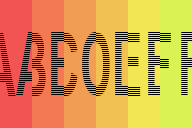

In [32]:
imgs = rearrange(images[:6], "b h (w2 w) c -> (h w2) (b w) c", w2=2)
display(Image.fromarray(imgs))

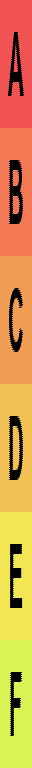

In [33]:
imgs = rearrange(images[:6], "b h (w w2) c -> (b h w2) w c", w2=2)
display(Image.fromarray(imgs))

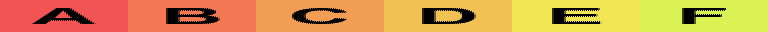

In [35]:
imgs = rearrange(images[:6], "b (h h2) w c -> h (b w h2) c", h2=2)
display(Image.fromarray(imgs))

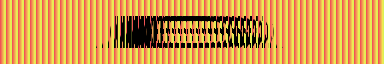

In [37]:
imgs = rearrange(images[:6], "b h w c -> h (w b) c")
display(Image.fromarray(imgs))

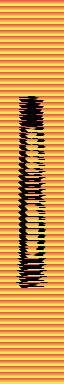

In [38]:
imgs = rearrange(images[:6], "b h w c -> (h b) w c")
display(Image.fromarray(imgs))

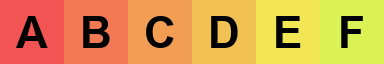

In [39]:
imgs = rearrange(images[:6], "(b1 b2) h w c -> h (b1 b2 w) c", b1=2)
display(Image.fromarray(imgs))

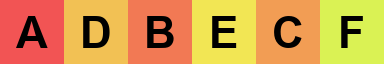

In [40]:
imgs = rearrange(images[:6], "(b1 b2) h w c -> h (b2 b1 w) c", b1=2)
display(Image.fromarray(imgs))

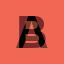

In [47]:
imgs = reduce(np.float32(images[:2]), "b h w c -> h w c", "mean")
display(Image.fromarray(np.uint8(imgs)))

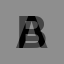

In [48]:
imgs = reduce(np.float32(images[:2]), "b h w c -> h w", "mean")
display(Image.fromarray(np.uint8(imgs)))

In [52]:
x = list(images[:6])
print(type(x), "with", len(x), "tensor of shape", x[0].shape)
rearrange(x, "b h w c -> b h w c").shape

<class 'list'> with 6 tensor of shape (64, 64, 3)


(6, 64, 64, 3)

In [53]:
rearrange(x, "b h w c -> h w c b").shape

(64, 64, 3, 6)

In [55]:
np.array_equal(rearrange(x, "b h w c -> h w c b"), np.stack(x, axis=3))

True

In [56]:
rearrange(x, "b h w c -> h (b w) c").shape

(64, 384, 3)

In [57]:
np.array_equal(rearrange(x, "b h w c -> h (b w) c"), np.concatenate(x, axis=1))

True

In [58]:
x = rearrange(images[:6], "b h w c -> b 1 h w 1 c") 
print(x.shape)
print(rearrange(x, "b 1 h w 1 c -> b h w c").shape) 

(6, 1, 64, 64, 1, 3)
(6, 64, 64, 3)


x shape: (6, 64, 64, 3)


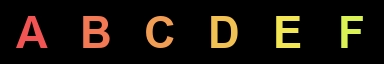

In [62]:
x = reduce(images[:6], "b h w c -> b () () c", "max") - images[:6]
print(f"x shape: {x.shape}")
display(Image.fromarray(rearrange(x, "b h w c -> h (b w) c")))

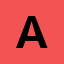

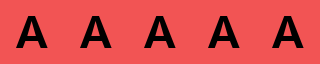

In [68]:
images_list = list(images[:6])
img = images_list[0]
display(Image.fromarray(img))

x = repeat(img, "h w c -> h new_axis w c", new_axis=5)
display(Image.fromarray(rearrange(x, "h new w c -> h (new w) c")))

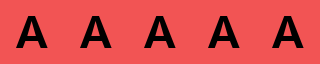

In [69]:
x = repeat(img, "h w c -> h (new_axis w) c", new_axis=5)
display(Image.fromarray(x))

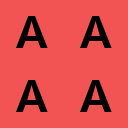

In [70]:
x = repeat(img, "h w c -> (2 h) (2 w) c")
display(Image.fromarray(x))

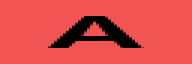

In [72]:
x = repeat(img, "h w c -> h (w 3) c")
display(Image.fromarray(x))

In [73]:
repeated = repeat(images[:6], "b h w c -> b h new_axis w c", new_axis=2)
reduced = reduce(repeated, "b h new_axis w c -> b h w c", "min")
assert np.array_equal(images[:6], reduced)